<a href="https://colab.research.google.com/github/FarsusDasdana/double-ml-colab/blob/main/DoubleMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


## Explain Double Machine Learning

### Subtask:
Provide a comprehensive explanation of Double Machine Learning (DML), its core principles, and its application in causal inference.


### Double Machine Learning (DML)

Double Machine Learning (DML) is a powerful framework that combines machine learning techniques with econometric principles to provide robust and valid statistical inference for causal effects. It is particularly useful in settings where traditional econometric methods might struggle due to high-dimensional data, complex relationships, or potential confounding.

#### Core Principles

1.  **Nuisance Parameters and Orthogonality**: In causal inference, we are often interested in estimating a causal effect (e.g., the effect of a treatment on an outcome) while controlling for other variables (covariates or confounders). These other variables introduce "nuisance parameters" – aspects of the data-generating process that are not the primary focus but must be accounted for to accurately estimate the causal effect.

    DML addresses these nuisance parameters by using a "double robustness" or "orthogonality" principle. This means that the estimator for the causal effect remains valid even if one of the machine learning models used to estimate the nuisance parameters is misspecified, as long as the other is correctly specified.

2.  **"Debiasing" using Two Separate Machine Learning Models**: The core idea behind DML is to "debias" the estimation of the causal effect. It achieves this by dividing the problem into two distinct prediction tasks, each handled by a separate machine learning model:

    *   **Model 1: Predicting the Outcome (Y) using Covariates (X)**: One machine learning model predicts the outcome variable (Y) based on the set of covariates (X). The residuals from this prediction represent the part of the outcome not explained by the covariates.
    *   **Model 2: Predicting the Treatment (D) using Covariates (X)**: A second machine learning model predicts the treatment status (D) based on the same set of covariates (X). The residuals from this prediction represent the part of the treatment not explained by the covariates.

    By using these residuals, DML effectively "nets out" the confounding effects of X on both Y and D, leading to a "debiased" estimate of the causal effect of D on Y. This process helps in isolating the true causal relationship.

#### Application in Causal Inference

DML is particularly useful for causal inference due to several key advantages:

1.  **Mitigation of Bias from Confounding Variables**: In observational studies, unobserved or poorly controlled confounding variables can lead to biased estimates of causal effects. DML explicitly tackles this by using machine learning models to flexibly control for high-dimensional confounders. By modeling the relationships between covariates and both the outcome and treatment, DML helps to remove the influence of these confounders, thus reducing bias.

2.  **Valid Statistical Inference, even with High-Dimensional Data**: Traditional methods for causal inference (like OLS with many controls) can suffer from issues like overfitting or poor small-sample performance in high-dimensional settings. DML allows for the use of complex, flexible machine learning models (e.g., Random Forests, Gradient Boosting, Neural Networks) to estimate the nuisance parameters, even when the number of covariates is large. Crucially, DML provides asymptotically normal and root-n consistent estimates of causal parameters, enabling valid hypothesis testing and confidence interval construction, which is often difficult with standard ML-based causal methods.

3.  **Robustness to Model Misspecification**: As mentioned in its core principles, DML's "double robustness" property means that the causal effect estimator remains valid even if one of the two nuisance models is misspecified. This provides a significant advantage over methods that rely on the correct specification of a single model.

#### Key Advantages

*   **Flexibility with Various Machine Learning Models**: DML is a meta-algorithm, meaning it can incorporate virtually any machine learning algorithm for its nuisance parameter estimation steps. This flexibility allows researchers to leverage the predictive power of state-of-the-art ML models.
*   **Robustness to Model Misspecification**: The double robustness property ensures reliable inference even if the models for outcome or treatment are not perfectly specified.
*   **Addresses High-Dimensionality**: It is well-suited for situations with many covariates, which are common in modern datasets, without suffering from the "curse of dimensionality" in the same way as traditional methods.
*   **Provides Valid Standard Errors**: Unlike many pure machine learning approaches to causal inference, DML explicitly provides valid standard errors and confidence intervals for causal effects, which are essential for statistical inference.

## Explain W, X, T, Y Variables

### Subtask:
Detail the roles and definitions of the W (controls/confounders), X (features/covariates), T (treatment), and Y (outcome) variables within the Double Machine Learning framework.


### Understanding Variables in Double Machine Learning (DML)

In the Double Machine Learning (DML) framework, certain variables play distinct roles in estimating causal effects while controlling for confounding. These variables are typically denoted as W, X, T, and Y.

#### 1. W (Controls/Confounders)
*   **Definition**: The `W` variables represent a set of control variables or confounders. These are observable characteristics that influence both the treatment assignment (`T`) and the outcome (`Y`).
*   **Role**: In causal inference, it's crucial to account for confounders to avoid spurious correlations. `W` variables are used to "de-confound" the relationship between `T` and `Y`, ensuring that any observed effect is truly attributable to `T` and not to other common causes.

#### 2. X (Features/Covariates)
*   **Definition**: The `X` variables are a broader set of features or covariates that describe the units in the study. These can include `W` variables and potentially other variables that might influence the outcome or treatment, but are not necessarily confounders in the strict sense (i.e., they might not affect both T and Y).
*   **Role**: `X` variables are used to build rich predictive models for both the treatment assignment (`T`) and the outcome (`Y`). While `W` specifically addresses confounding, `X` provides a more general set of predictors to improve the accuracy of these nuisance models, which indirectly helps in isolating the treatment effect.

#### 3. T (Treatment)
*   **Definition**: The `T` variable represents the treatment, intervention, or policy whose causal effect on the outcome `Y` is of primary interest. `T` can be binary (e.g., treated vs. control), continuous (e.g., dosage), or categorical.
*   **Role**: The goal of DML is to estimate the causal effect of `T` on `Y` while appropriately accounting for confounding and other factors. `T` is the 'cause' whose 'effect' we are trying to measure.

#### 4. Y (Outcome)
*   **Definition**: The `Y` variable is the outcome, response, or dependent variable that is hypothesized to be affected by the treatment `T`.
*   **Role**: `Y` is the variable we observe and measure to assess the impact of the treatment. The DML framework aims to quantify how changes in `T` lead to changes in `Y`, net of other influences.

#### Interaction within the DML Framework

The DML framework works by breaking down the complex causal estimation problem into two simpler machine learning tasks, often referred to as "nuisance regressions." The core idea is to "partial out" the effects of `W` (and `X`) from both `T` and `Y` before estimating the causal effect.

1.  **Modeling Treatment (`T`)**: A machine learning model is trained to predict the treatment `T` using the `W` (or `X`) variables. Let's denote this as `T_hat = m(W)`.
2.  **Modeling Outcome (`Y`)**: Another machine learning model is trained to predict the outcome `Y` using the `W` (or `X`) variables. Let's denote this as `Y_hat = g(W)`.

These predictions (`T_hat` and `Y_hat`) capture the variation in `T` and `Y` that can be explained by the confounders/covariates `W` (or `X`).

Next, the residuals from these two models are computed:

*   **Residualized Treatment**: `T_tilde = T - T_hat` (The part of `T` not explained by `W`)
*   **Residualized Outcome**: `Y_tilde = Y - Y_hat` (The part of `Y` not explained by `W`)

By regressing `Y_tilde` on `T_tilde`, DML effectively removes the confounding influence of `W` (or `X`), allowing for an unbiased and more robust estimation of the causal effect of `T` on `Y`. The use of cross-fitting helps to prevent overfitting from the initial machine learning models used to estimate `m(W)` and `g(W)`, further ensuring the validity of the causal effect estimate.

## Limitations of Vanilla ML

### Subtask:
Explain why vanilla machine learning models are not suitable for estimating causal effects like price elasticity, focusing on issues such as confounding bias and the goal of prediction vs. causation.


Vanilla machine learning models, often referred to as 'traditional' or 'vanilla' ML, are primarily designed for **prediction**, not for estimating **causal effects**. While they excel at identifying patterns and making accurate forecasts based on input data, their inherent structure often makes them unsuitable for understanding direct cause-and-effect relationships.

### Confounding Bias
One of the main issues is **confounding bias**. In observational data, many variables are correlated. A vanilla ML model might pick up on these correlations and use them for prediction. However, if an unobserved or unmeasured variable influences both the 'cause' (e.g., price) and the 'effect' (e.g., demand), the model's output will be biased when interpreted causally. For example, a sudden promotional event might simultaneously lower prices and increase demand. A predictive model might learn that lower prices correlate with higher demand, but it won't be able to disentangle how much of the demand increase is due to the price drop itself versus the promotional buzz, which is a confounding factor.

### Prediction vs. Causation
*   **Prediction** focuses on answering "What will happen?" or "What is the most likely outcome given these inputs?". The goal is to maximize the accuracy of the forecast, often by leveraging any statistical associations found in the data, regardless of their causal nature.
*   **Causation** (or causal inference) aims to answer "What would happen if I intervene and change X?" or "Does changing X *cause* a change in Y, and by how much?". This requires understanding the underlying data generating process and isolating the effect of a specific variable while holding all other factors constant, which is a much more stringent requirement.

### Application to Price Elasticity
Consider estimating **price elasticity**, which measures the responsiveness of demand to a change in price. A vanilla predictive model might observe a correlation between lower prices and higher sales. However, this correlation could be driven by various factors: competitor pricing changes, seasonal trends, marketing campaigns, or even macroeconomic shifts. A simple predictive model would identify these correlations to predict future demand but would struggle to isolate the *causal impact* of a price change on demand, independent of these other confounding factors. Without careful consideration and specific causal inference techniques, the model's output for price elasticity would likely be biased, leading to incorrect business decisions about pricing strategies.

## EconML Example Setup

### Subtask:
Set up a simple, illustrative example for estimating price elasticity using synthetic data. This will include defining the treatment (price), outcome (demand/sales), and relevant confounders/covariates.


**Reasoning**:
To begin setting up the EconML example, I will first import the necessary libraries (`numpy` and `pandas`), define the parameters for synthetic data generation, and then generate the synthetic data for confounders, treatment (price), and outcome (demand/sales), ensuring that confounders influence both treatment and outcome. Finally, I will combine these into a pandas DataFrame and display its head and descriptive statistics to inspect the generated data.



In [ ]:
import numpy as np
import pandas as pd

def generate_synthetic_data(n=1000, seed=42):
    np.random.seed(seed)

    # -----------------------------
    # Base exogenous variables
    # -----------------------------
    region = np.random.choice([0, 1, 2, 3], n)
    season = np.random.choice([0, 1, 2, 3], n)
    age = np.random.uniform(20, 60, n)
    income = np.random.uniform(20000, 80000, n)

    # -----------------------------
    # Price generation
    # -----------------------------
    base_price = 3

    price = (
        base_price
        + 0.2 * region
        + 0.5 * season
        - 0.00002 * income
        + 0.01 * age
        + np.random.normal(0, 0.4, n)  # noise
    )

    price = np.clip(price, 1, 8)

    # -----------------------------
    # Competitor price
    # -----------------------------
    competitor_price = (
        price * 0.7
        + np.random.normal(0, 0.6, n)
    )

    competitor_price = np.clip(competitor_price, 1, 8)

    # -----------------------------
    # Demand generation
    # -----------------------------
    base_demand = 10

    demand = (
        base_demand
        - 3.0 * price
        + 1.5 * competitor_price
        + 0.2 * region
        + 0.4 * season
        + 0.007 * income
        - 0.015 * age
        + np.random.normal(0, 2.5, n)
    )

    demand = np.clip(demand, 0, None)

    # -----------------------------
    # Past demand (very noisy)
    # -----------------------------
    past_demand = demand + np.random.normal(0, 8, n)

    past_demand = np.clip(past_demand, 0, None)

    df = pd.DataFrame({
        "price": price,                # T
        "demand": demand,              # Y
        "income": income,              # X
        "past_demand": past_demand,    # W
        "competitor_price": competitor_price, # W
        "season": season,              # W
        "age": age,                    # W
        "region": region               # W
    })

    return df


df = generate_synthetic_data(1000)

# Display the first few rows and descriptive statistics
print("\nDataFrame Descriptive Statistics:")
print(df.describe())
print("\n")
df.corr()


DataFrame Descriptive Statistics:
             price       demand        income  past_demand  competitor_price  \
count  1000.000000  1000.000000   1000.000000  1000.000000       1000.000000   
mean      3.414635   354.572439  50144.343566   354.277283          2.379072   
std       0.790147   122.911315  17440.451730   123.138458          0.791119   
min       1.203635   140.836130  20000.698085   135.762263          1.000000   
25%       2.856943   252.094141  35681.058632   252.009305          1.820603   
50%       3.445472   353.730502  50036.835177   352.154954          2.349614   
75%       3.961189   463.349926  65546.211650   461.267589          2.941278   
max       6.078760   565.389647  79869.251341   573.949091          5.288842   

            season          age       region  
count  1000.000000  1000.000000  1000.000000  
mean      1.414000    40.280692     1.534000  
std       1.095356    11.687596     1.151595  
min       0.000000    20.128731     0.000000  
25%      

,price,demand,income,past_demand,competitor_price,season,age,region
price,1.000000,-0.438542,-0.431282,-0.440347,0.675639,0.685199,0.129250,0.292254
demand,-0.438542,1.000000,0.999734,0.997864,-0.278936,-0.002622,0.023857,-0.030915
income,-0.431282,0.999734,1.000000,0.997601,-0.279543,0.002068,0.027262,-0.029391
past_demand,-0.440347,0.997864,0.997601,1.000000,-0.277727,-0.005640,0.024686,-0.029513
competitor_price,0.675639,-0.278936,-0.279543,-0.277727,1.000000,0.485417,0.078025,0.186193
season,0.685199,-0.002622,0.002068,-0.005640,0.485417,1.000000,0.021981,0.025334
age,0.129250,0.023857,0.027262,0.024686,0.078025,0.021981,1.000000,-0.020702
region,0.292254,-0.030915,-0.029391,-0.029513,0.186193,0.025334,-0.020702,1.000000


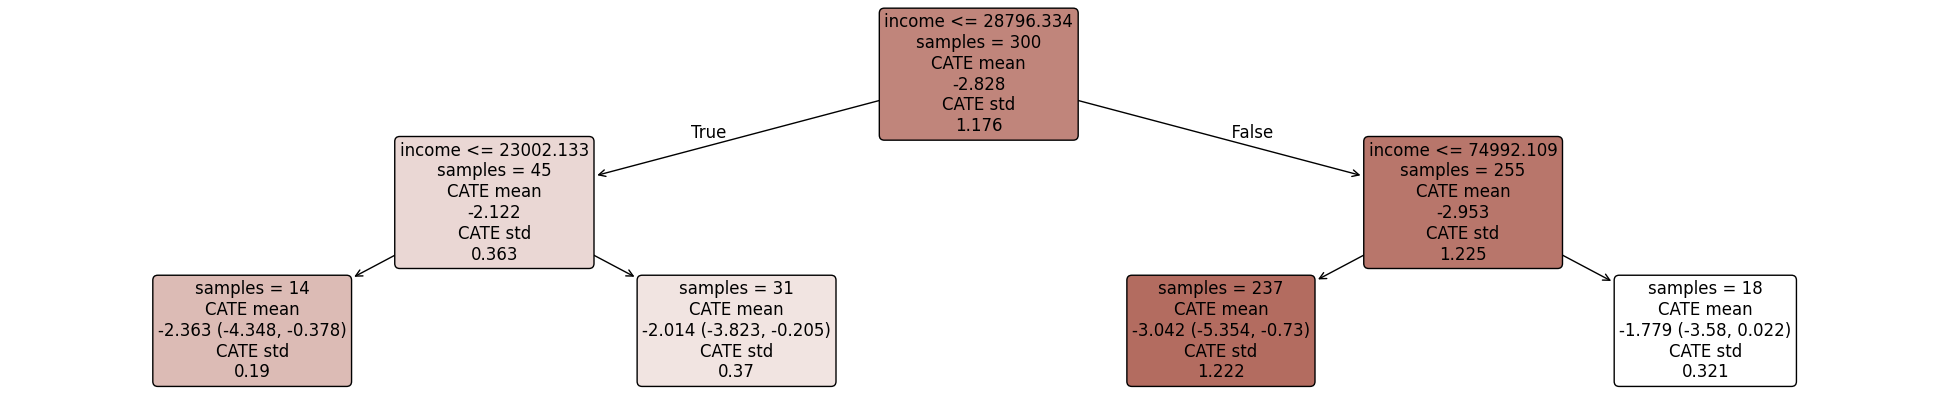

In [ ]:
import matplotlib.pyplot as plt
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter

from econml.dml import CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor


Y = df["demand"]  # outcome of interest
T = df["price"]  # intervention, or treatment
X = df[["income"]]  # features
W = df.drop(columns=["demand", "price", "income"])

# Get test data
X_test = X.values[:300].flatten() + np.random.normal(0, 2.5, 300)
X_test = pd.DataFrame(X_test, columns=["income"])


est = CausalForestDML(
    model_y=GradientBoostingRegressor(),
    model_t=GradientBoostingRegressor()
)

est.fit(Y=Y,
        T=T,
        X=X,
        W=W,
        #inference="blb"
      )
# Get treatment effect and its confidence interval
te_pred = est.effect(X_test)
te_pred_interval = est.effect_interval(X_test)

# Visualize the decision process
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, max_depth=2, min_samples_leaf=10)
intrp.interpret(est, X_test)
plt.figure(figsize=(25, 5))
intrp.plot(feature_names=X.columns, fontsize=12)
